# code to run pseudobulk deg analysis in converters of longitudinal ALTRA cohort

## related to Fig 7F

- normalized the count by deseq2
- model formula in female converters **count ~ age_conv + bmi_conv + days_to_conversion +
  (1 | subject.subjectGuid)**


In [1]:
# load packages
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}

quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("data.table")
quiet_library("broom.mixed")

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
Warning message:
“package ‘data.table’ was built under R version 4.4.3”


In [2]:
set.seed(1234)

In [3]:
# define working path
data_path <- "/home/workspace/data/ra_longitudinal/scrna/certPro"
fig_path <- "/home/workspace/data/ALTRA_manusript/figures"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
proj_name <- "ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3_"

In [4]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [5]:
source("/home/workspace/github/ALTRA-manuscript/Analysis/scRNA/ALTRA_scRNA_R_helper_functions.r")

## plot Fig S7A gene expression and model fit


In [11]:
# define a color scheme individuals
subj_colors_list <- read_csv(
    file.path(
        '/home/workspace/github/ALTRA-manuscript/Analysis/scRNA',
        "ALTRA_longtidunal_subject_colors.csv"
    ),
    show_col_types = FALSE
)
subject_colors <- c(subj_colors_list$subj_colors)
names(subject_colors) <- subj_colors_list$subject.subjectGuid

scale_color_subj <- function(colors = subject_colors, ...) {
    ggplot2:::manual_scale(
        "color",
        values = colors,
        ...
    )
}

# define a function to plot linear mixed model fit for individual gene
plotFitLmer <- function(fit, gene) {
    # extract the fit data
    fit_data <- fit[[gene]]@frame
    predicted_values <- modelr::data_grid(
        fit_data, age_conv, bmi_conv,
        days_to_conversion, subject.subjectGuid
    ) %>%
        modelr::add_predictions(fit[[gene]])
    # plot the residue
    df_model <- broom.mixed::augment(fit[[gene]])
    df_model[".stdresid"] <- resid(fit[[gene]], type = "pearson")

    # plot the predicted regression line
    p2 <- fit_data %>% ggplot(aes(x = days_to_conversion, y = count)) +
        geom_line(aes(color = subject.subjectGuid)) +
        geom_point(aes(color = subject.subjectGuid)) +
        stat_smooth(
            data = predicted_values, method = "lm", se = FALSE,
            aes(x = days_to_conversion, y = pred, color = subject.subjectGuid)
        ) +
        ggtitle(gene) +
        scale_color_subj() +
        theme_bw() +
        ylab("Normalized count")
    return(p2)
}

#' Plot a frequency line plot with prediction
#'
#' This function takes a frequency table, a model fit, and various parameters to create a line plot with prediction.
#'
#' @param frequency_table A data frame containing the frequency data.
#' @param model_fit The model fit object.
#' @param palette A vector of colors for the line plot.
#' @param fig_path The file path to save the plot. Default is NULL.
#' @param fig_name The name of the figure Default is NULL.
#' @param x_var The variable for the x-axis. Default is "days_to_conversion".
#' @param y_var The variable for the y-axis. Default is "clr".
#' @param color_var The variable for coloring the lines. Default is "subject.subjectGuid".
#' @param shape_var The variable for shaping the points. Default is "sex".
#' @param title The title of the plot. Default is "Cluster 9".
#' @param x_label The label for the x-axis. Default is "Days to Conversion".
#' @param y_label The label for the y-axis. Default is "CLR".
#' @param annotation_text The text for the annotation. Default is "p=0.055".
#' @param annotation_x The x-coordinate for the annotation. Default is -600.
#' @param annotation_y The y-coordinate for the annotation. Default is 1.
#' @param annotation_color The color for the annotation. Default is "red".
#'
#' @return The plot object.
#'
#' @examples
#' # Example usage of PlotFreqLinePlot function
#' PlotFreqLinePlot(frequency_table, model_fit, palette,
#'     fig_path = "path/to/save", fig_name = "fig_name",
#'     x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
#'     shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion",
#'     y_label = "CLR", annotation_text = "p=0.055", annotation_x = -600,
#'     annotation_y = 1, annotation_color = "red"
#' )
#'
#' @export
PlotPredLinePlot <- function(model_fit, fig_path = NULL, fig_name = NULL,
                             x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
                             shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion",
                             y_label = "CLR") {
    require(ggplot2)
    require(ggeffects)

    # Extract the prediction data frame

    pred.mm <- ggpredict(model_fit, terms = c(x_var)) # Adjusted to use x_var
    fit_data <- model_fit@frame
    # plot
    p1 <- fit_data %>%
        ggplot() +
        geom_line(aes(x = .data[[x_var]], y = .data[[y_var]], color = .data[[color_var]]), size = 1) +
        geom_point(aes(x = .data[[x_var]], y = .data[[y_var]])) +
        geom_line(data = pred.mm, aes(x = x, y = predicted), color = "#8F7700FF", size = 1.2) +
        geom_ribbon(
            data = pred.mm, aes(x = x, ymin = predicted - std.error, ymax = predicted + std.error),
            fill = "#8F7700FF", alpha = 0.3, size = 1.2
        ) +
        labs(title = title) +
        xlab(x_label) +
        ylab(y_label) +
        scale_color_subj() +
        ggpubr::theme_pubr() +
        scale_shape_manual(values = c(1, 2)) +
        guides(color = FALSE)

    # Code to save the plot if fig_path and proj_name are provided
    # Check if fig_path and proj_name are provided and not empty
    if (!missing(fig_path) && !missing(fig_name) && nzchar(fig_path) && nzchar(fig_name)) {
        # Construct the full file path with the project name and desired file extension
        file_name <- paste0(fig_path, "/", fig_name)
        # Use ggsave to save the plot
        ggsave(file_name, plot = p1, width = 4, height = 4, dpi = 300)
    }
    return(p1)
}


# load deg model results 
- model output from 01_R_Pseudobulk_longitudinal_DEGs.ipynb 

In [7]:
# load the model output from AIM3 deg
aim3_cd4na_model <- readRDS(
  "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/output_results_oldIDE/output_results/pseudobulk/certPro/model_output/ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3__Core naive CD4 T cell_lme4_vst_models.rds"
)

Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”


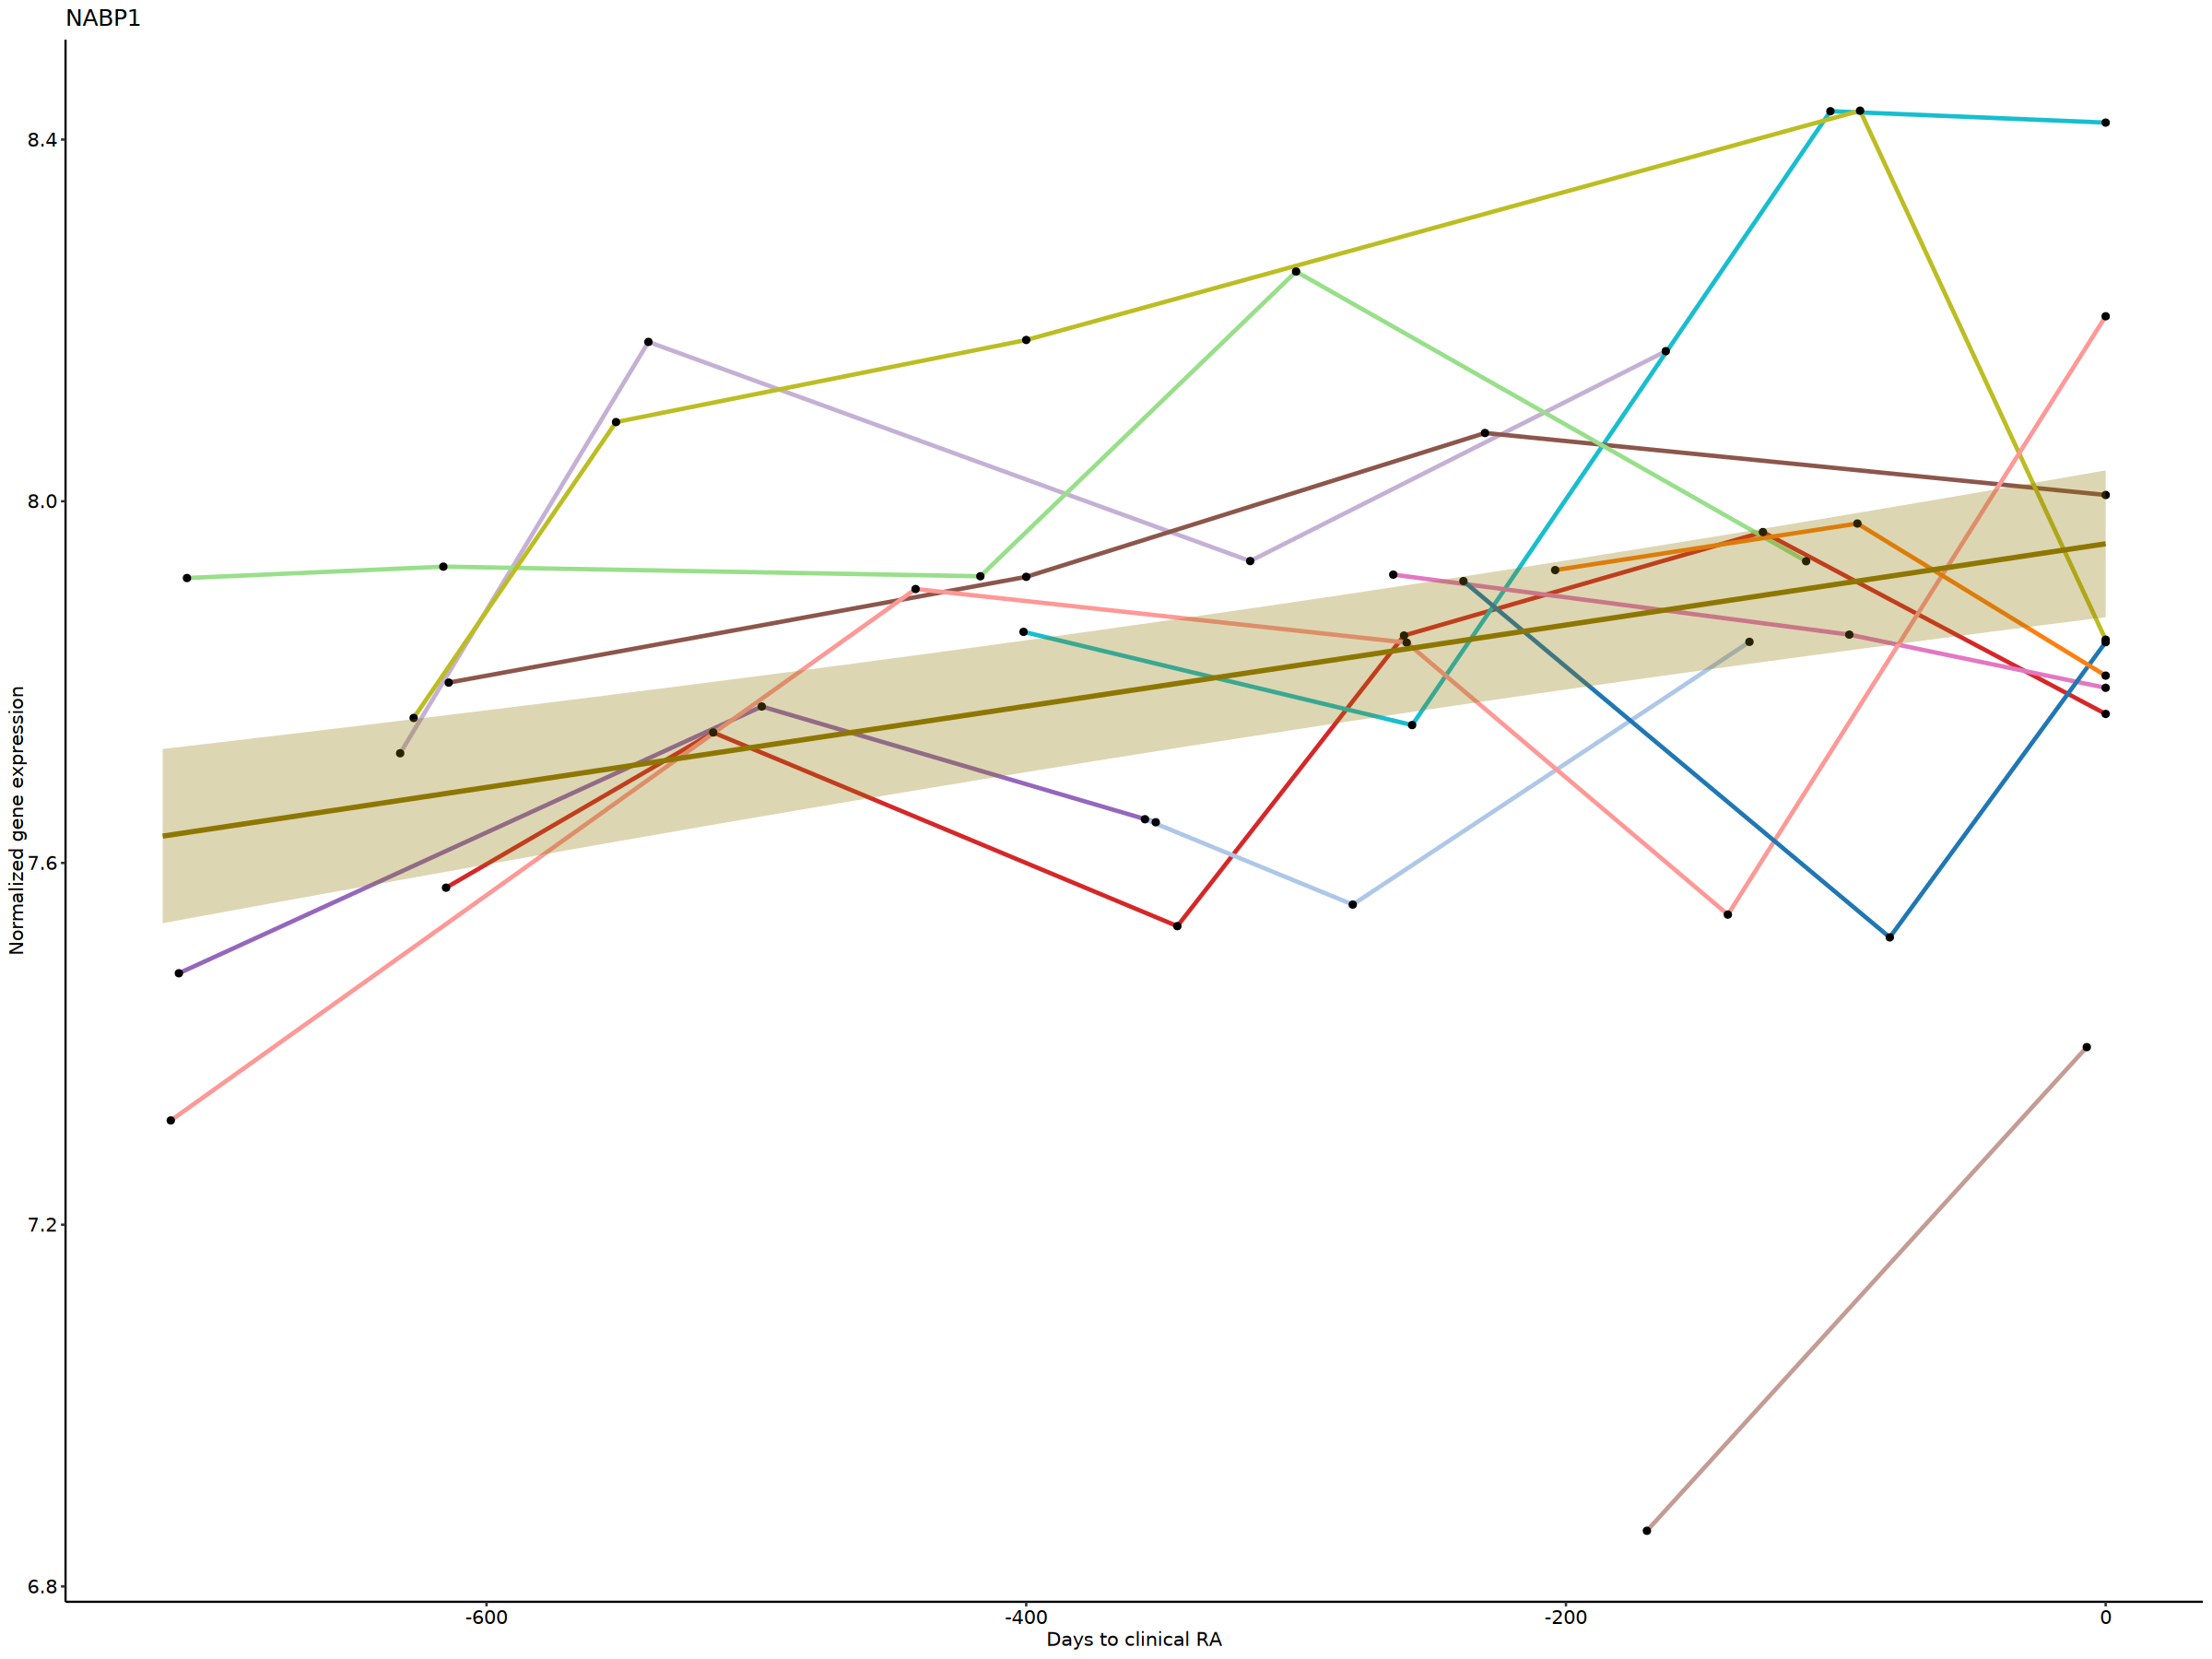

In [12]:
gene_plot <- "NABP1"
p <- PlotPredLinePlot(aim3_cd4na_model[[gene_plot]],
  y_var = "count", shape_var = NULL,
  title = gene_plot, y_label = "Normalized gene expression"
)
p + labs(
  title = "NABP1",
  x = "Days to clinical RA"
)
ggsave(file.path(fig_path, paste0(proj_name, gene_plot, "_model_expression.pdf")), width = 3, height = 3)

In [13]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lmerTest_3.1-3      lme4_1.1-37         Matrix_1.7-3       
 [4] ggeffects_2.2.1     broom.mixed_0.2.9.6 data.table_1.17.8  
 [7] lubridate_1.9.4     forcats_1.0.0       stringr_1.5.1      
[10] dplyr_1.1.4         purrr_1.1.0         readr_2.1.5        
[13] tidyr_1.3.1         tibble_3.2.1        ggplot2_3.5.2   